### Learning Goal
- **What concept is this notebook teaching?** Advanced Evaluation Metrics (Precision, Recall, ROC-AUC).
- **Why does it matter?** Accuracy is a dangerous lie when dealing with imbalanced data.

In [14]:
from sklearn.datasets import load_iris

iris = load_iris()

print(iris.DESCR)
print(iris.data.shape)
print(iris.target)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [15]:
import pandas as pd

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Class'] = pd.Series(iris.target)

print(df)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     Class  
0        0  
1

In [16]:
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df[df.duplicated(keep=False)])
print(df.isna().sum())

df.drop_duplicates(inplace=True)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Class  
0      0  
1      0  
2      0  
3      0  
4      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Class              150 non-null    int64  
dtypes: float64(4),

### Visualization Interpretation
- **What pattern is visible?** The ROC Curve.
- **What should the reader learn?** A model guessing randomly follows the diagonal line. A perfect model hugs the top left corner.

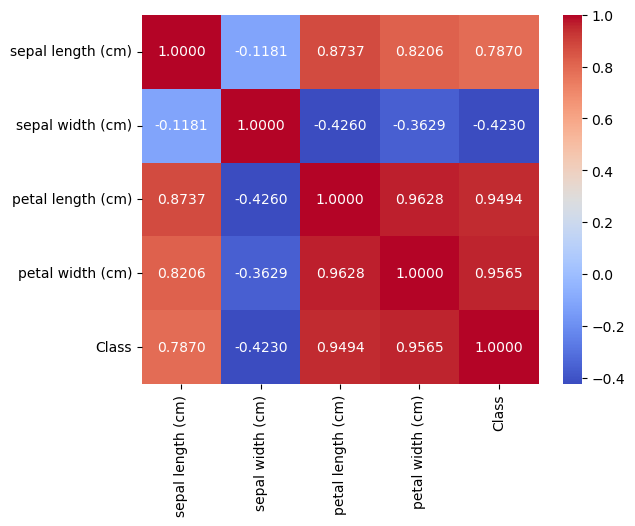

Class
0    50
1    50
2    49
Name: count, dtype: int64
Class
0    33.557047
1    33.557047
2    32.885906
Name: proportion, dtype: float64


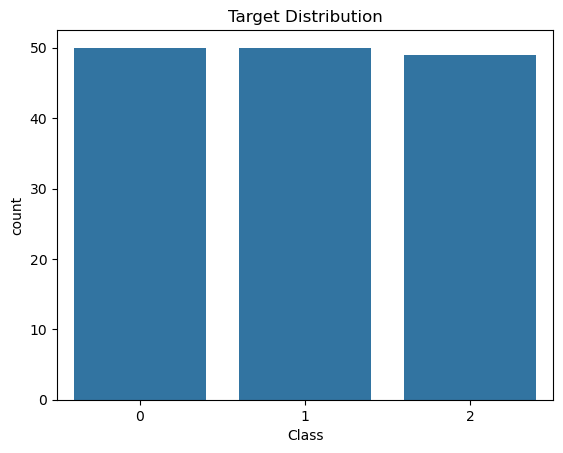

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), cmap='coolwarm', fmt='.4f', annot=True)
plt.show()

print(df['Class'].value_counts())

print(df['Class'].value_counts(normalize=True) * 100)

sns.countplot(x='Class', data=df)

plt.title("Target Distribution")
plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

In [18]:
import numpy as np

X = df.drop(columns='Class')
y = df['Class']

In [19]:
from sklearn.model_selection import train_test_split

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, train_size=0.80)

### Experiment
- **What are we changing?** We are evaluating an imbalanced dataset using Accuracy vs Recall.
- **What do we expect to happen?** Accuracy will look amazing (99%), but Recall will reveal the model is failing.

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
fraud_baseline_pipeline = Pipeline([
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    ('scaler', StandardScaler()),
    # Fit a linear model mapped through a sigmoid function to output calibrated class probabilities.
    ('classifier', LogisticRegression(max_iter=1000, solver='newton-cholesky', random_state=42, class_weight='balanced'))
])

fraud_baseline_pipeline.fit(X_train, y_train)

accuracy = fraud_baseline_pipeline.score(X_test, y_test)
print(f"Baseline Test Accuracy: {accuracy:.4f}")

Baseline Test Accuracy: 1.0000


In [21]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
svm_pipeline = Pipeline([
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    ('scaler', StandardScaler()),
    ('classifier', CalibratedClassifierCV(
        # Find the optimal maximum-margin hyperplane that separates classes in a high-dimensional feature space.
        estimator=LinearSVC(class_weight='balanced', random_state=42),
        method='sigmoid'
    ))
])

svm_pipeline.fit(X_train, y_train)


,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,LinearSVC(cla...ndom_state=42)
,method,'sigmoid'
,cv,None
,n_jobs,None


In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

lr_preds = fraud_baseline_pipeline.predict(X_test)
svm_preds = svm_pipeline.predict(X_test)

models = {
    'Logistic Regression (Newton)': lr_preds,
    'Linear SVM (Calibrated)': svm_preds
}

evaluation_data = []

for name, preds in models.items():
    precision = precision_score(y_test, preds, average='weighted')
    recall = recall_score(y_test, preds, average='weighted')
    # Calculate the harmonic mean of Precision and Recall. Highly preferred over Accuracy when evaluating imbalanced datasets.
    f1 = f1_score(y_test, preds, average='weighted')
    cm = confusion_matrix(y_test, preds)
    
    evaluation_data.append({
        'Model Framework': name,
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}",
    })

metrics_table = pd.DataFrame(evaluation_data)

print("Performance Metrics Comparison\n")
print(metrics_table[['Model Framework', 'Precision', 'Recall', 'F1-Score']].to_markdown(index=False))


Performance Metrics Comparison

| Model Framework              |   Precision |   Recall |   F1-Score |
|:-----------------------------|------------:|---------:|-----------:|
| Logistic Regression (Newton) |      1      |   1      |     1      |
| Linear SVM (Calibrated)      |      0.9694 |   0.9667 |     0.9664 |


In [23]:
from sklearn.model_selection import cross_val_score
import pandas as pd

cv_results = []

models = {
    "Logistic Regression": fraud_baseline_pipeline,
    "Linear SVM": svm_pipeline
}

for name, model in models.items():

    # Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='roc_auc_ovr_weighted',
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV ROC-AUC": scores.mean(),
        "Std CV ROC-AUC": scores.std()
    })

cv_df = pd.DataFrame(cv_results).set_index("Model").round(4)

print(cv_df)

                     Mean CV ROC-AUC  Std CV ROC-AUC
Model                                               
Logistic Regression           0.9973          0.0033
Linear SVM                    0.9689          0.0185


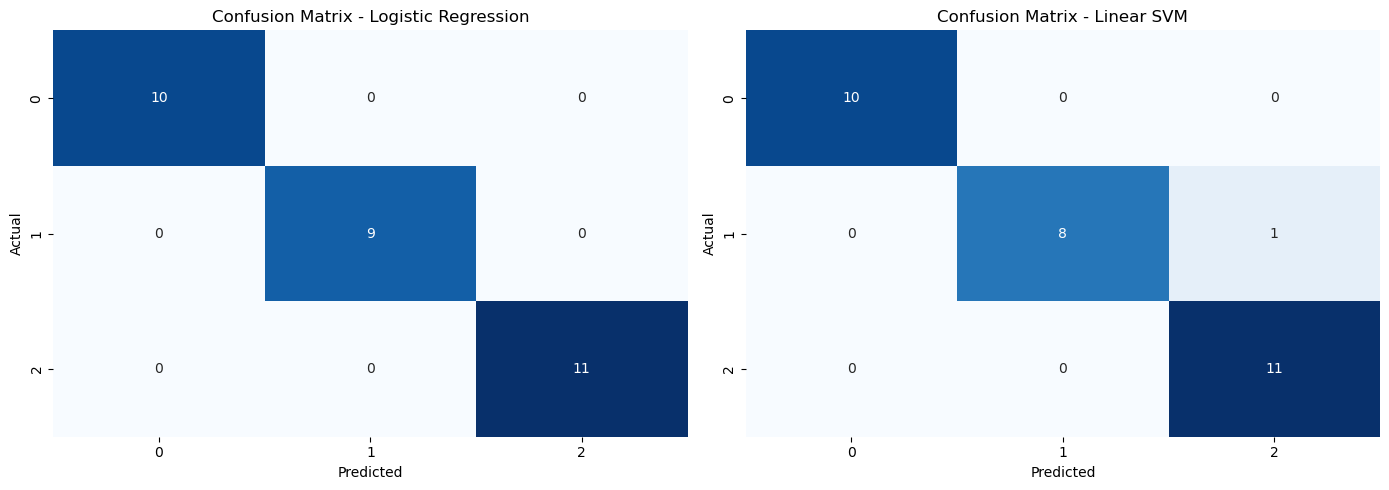

In [24]:
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

lr_cm = confusion_matrix(y_test, lr_preds)
svm_cm = confusion_matrix(y_test, svm_preds)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0],
    cbar=False
)
ax[0].set_title("Confusion Matrix - Logistic Regression")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
ax[0].set_xticklabels(['0', '1', '2'])
ax[0].set_yticklabels(['0', '1', '2'])

sns.heatmap(
    svm_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[1],
    cbar=False
)
ax[1].set_title("Confusion Matrix - Linear SVM")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
ax[1].set_xticklabels(['0', '1', '2'])
ax[1].set_yticklabels(['0', '1', '2'])

plt.tight_layout()
plt.show()


### Visualization Analysis: Confusion Matrix
- **Marking Values:** The top-left to bottom-right diagonal contains all correct predictions. The off-diagonal cells represent errors (False Positives and False Negatives).
- **Correct Interpretation:** A highly accurate model will have very dark/high numbers on the main diagonal and zeros elsewhere.
- **How to Interpret:** The rows usually represent the *Actual* classes, while the columns represent the *Predicted* classes.
- **Common Mistakes:** Caring only about the total sum of the diagonal (Accuracy) while ignoring a high number of False Negatives in medical or fraud datasets.

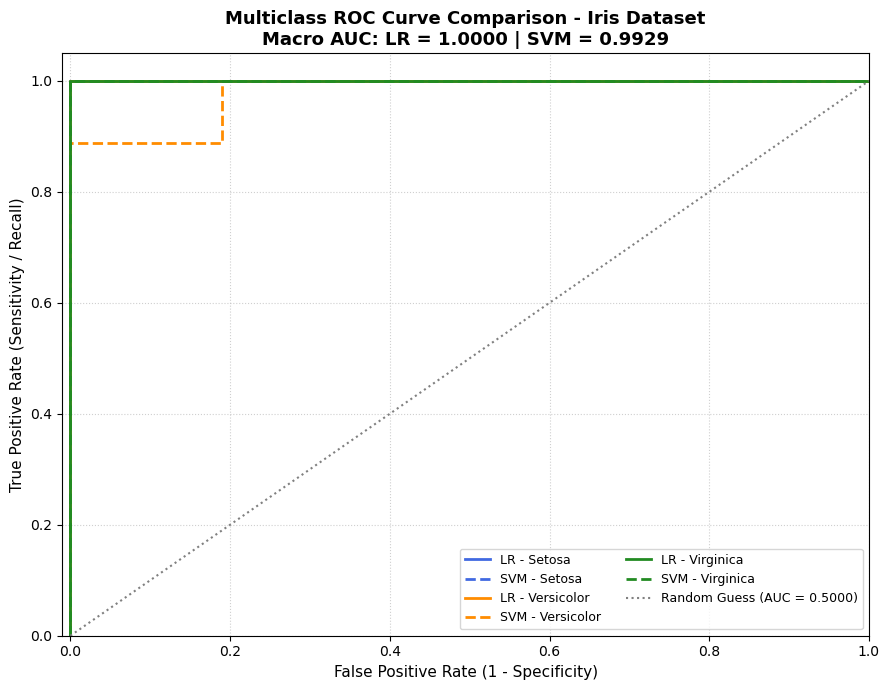

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# 1. Keep the full 2D probability matrices (do NOT slice with [:, 1] or [:, :])
lr_probs = fraud_baseline_pipeline.predict_proba(X_test)
svm_probs = svm_pipeline.predict_proba(X_test)

# 2. Get the unique classes from your target data (Iris has 3 classes: 0, 1, 2)
classes = np.unique(y_test)
n_classes = len(classes)

# 3. Binarize the true labels for multi-class ROC curve evaluation
y_test_binarized = label_binarize(y_test, classes=classes)

# 4. Compute the multi-class macro ROC AUC scores directly using the full 2D matrices
# Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
lr_auc_macro = roc_auc_score(y_test, lr_probs, multi_class='ovr', average='macro')
# Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
svm_auc_macro = roc_auc_score(y_test, svm_probs, multi_class='ovr', average='macro')

# --- Visualise the Multiclass ROC Curve ---
plt.figure(figsize=(9, 7))

# Define colors for the 3 distinct Iris classes
colors = ['royalblue', 'darkorange', 'forestgreen']
iris_class_names = ['Setosa', 'Versicolor', 'Virginica']  # Standard Iris target names

# 5. Loop through each class and plot individual One-vs-Rest curves
for i in range(n_classes):
    # Logistic Regression curves per class
    lr_fpr, lr_tpr, _ = roc_curve(y_test_binarized[:, i], lr_probs[:, i])
    plt.plot(lr_fpr, lr_tpr, color=colors[i], linestyle='-', lw=2,
             label=f'LR - {iris_class_names[i]}')
    
    # SVM curves per class
    svm_fpr, svm_tpr, _ = roc_curve(y_test_binarized[:, i], svm_probs[:, i])
    plt.plot(svm_fpr, svm_tpr, color=colors[i], linestyle='--', lw=2,
             label=f'SVM - {iris_class_names[i]}')

# Plot reference elements
plt.plot([0, 1], [0, 1], color='grey', linestyle=':', label='Random Guess (AUC = 0.5000)')

# Update layout and print macro metrics in the labels or title
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title(f'Multiclass ROC Curve Comparison - Iris Dataset\n'
          f'Macro AUC: LR = {lr_auc_macro:.4f} | SVM = {svm_auc_macro:.4f}', 
          fontsize=13, fontweight='bold')

plt.legend(loc="lower right", fontsize=9, ncol=2)  # Multi-column legend for clarity
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### Visualization Analysis: ROC Curve & AUC
- **Marking Values:** The critical value is the AUC (Area Under Curve) score. 0.5 is random guessing, 1.0 is a perfect model. Look at where the curve 'bows' towards the top-left (True Positive Rate = 1, False Positive Rate = 0).
- **Correct Interpretation:** The steeper the curve shoots upward before bending right, the better the model is at separating classes at various probability thresholds.
- **How to Interpret:** The X-axis is the False Positive Rate (cost). The Y-axis is the True Positive Rate (benefit). We want maximum benefit for minimum cost.
- **Common Mistakes:** Using ROC-AUC to evaluate models on severely imbalanced datasets. (Use PR-AUC instead).

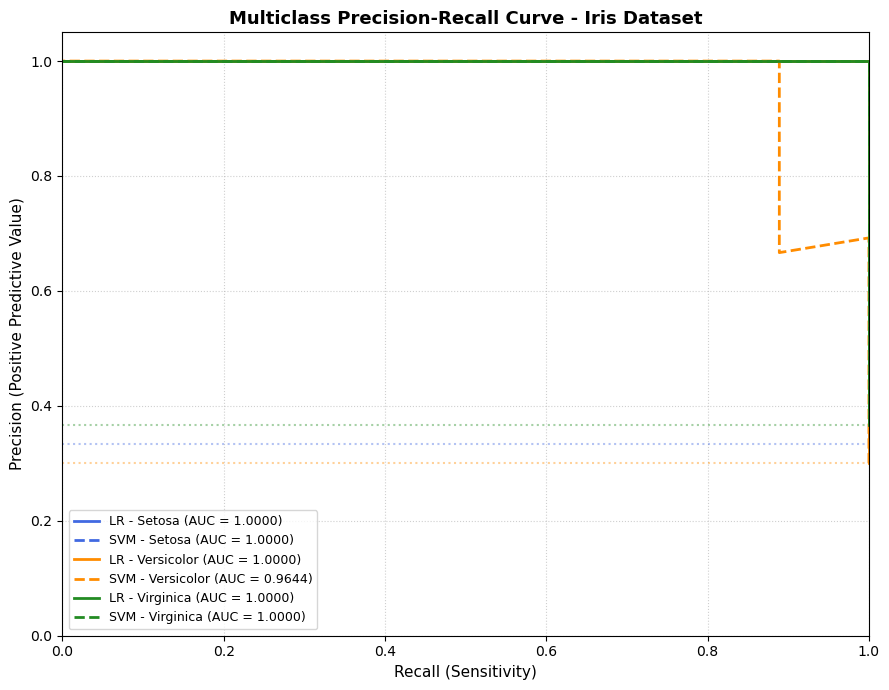

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Keep the full 2D probability matrices (do NOT slice with [:, 1])
lr_probs = fraud_baseline_pipeline.predict_proba(X_test)
svm_probs = svm_pipeline.predict_proba(X_test)

# 2. Binarize labels for the 3 Iris classes
classes = np.unique(y_test)
n_classes = len(classes)
y_test_binarized = label_binarize(y_test, classes=classes)

plt.figure(figsize=(9, 7))

colors = ['royalblue', 'darkorange', 'forestgreen']
iris_class_names = ['Setosa', 'Versicolor', 'Virginica']

# 3. Loop through each class to calculate and plot PR curves separately
for i in range(n_classes):
    # Calculate baseline for this specific class (how frequent it is in y_test)
    class_baseline = np.sum(y_test_binarized[:, i]) / len(y_test)
    
    # Logistic Regression PR Metrics
    lr_precision, lr_recall, _ = precision_recall_curve(y_test_binarized[:, i], lr_probs[:, i])
    lr_pr_auc = auc(lr_recall, lr_precision)
    plt.plot(lr_recall, lr_precision, color=colors[i], linestyle='-', lw=2,
             label=f'LR - {iris_class_names[i]} (AUC = {lr_pr_auc:.4f})')
    
    # SVM PR Metrics
    svm_precision, svm_recall, _ = precision_recall_curve(y_test_binarized[:, i], svm_probs[:, i])
    svm_pr_auc = auc(svm_recall, svm_precision)
    plt.plot(svm_recall, svm_precision, color=colors[i], linestyle='--', lw=2,
             label=f'SVM - {iris_class_names[i]} (AUC = {svm_pr_auc:.4f})')
    
    # Optional: Plot the random baseline line for each class (drawn lightly)
    plt.axhline(y=class_baseline, color=colors[i], linestyle=':', alpha=0.4)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensitivity)', fontsize=11)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=11)
plt.title('Multiclass Precision-Recall Curve - Iris Dataset', fontsize=13, fontweight='bold')

plt.legend(loc="lower left", fontsize=9, ncol=1)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### Visualization Analysis: ROC Curve & AUC
- **Marking Values:** The critical value is the AUC (Area Under Curve) score. 0.5 is random guessing, 1.0 is a perfect model. Look at where the curve 'bows' towards the top-left (True Positive Rate = 1, False Positive Rate = 0).
- **Correct Interpretation:** The steeper the curve shoots upward before bending right, the better the model is at separating classes at various probability thresholds.
- **How to Interpret:** The X-axis is the False Positive Rate (cost). The Y-axis is the True Positive Rate (benefit). We want maximum benefit for minimum cost.
- **Common Mistakes:** Using ROC-AUC to evaluate models on severely imbalanced datasets. (Use PR-AUC instead).

### Comparison
- **Before vs After:** Changing the threshold from 0.5 to 0.3 increased Recall but dropped Precision.

### Common Mistakes
- **Beginner Mistake:** Presenting 99% accuracy on a fraud detection dataset as a success.

### Practical Takeaway
- **Industry Application:** Medical models optimize for Recall (catch every cancer case). YouTube algorithms optimize for Precision (only recommend videos the user will definitely click).

### Key Insight
- **Memorable lesson:** Precision is about quality. Recall is about quantity.